# 4-2확률적 경사 하강법

## 4️⃣ SGDClassifier 사용하기

In [96]:
# SGD : Stochastic Gradient Descent, 확률적 기울기 하강법

### 데이터 전처리

In [97]:
import pandas as pd

fish = pd.read_csv('./data/fish.csv')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [98]:
fish_input = fish[['Weight','Length','Diagonal','Height','Width']]
fish_target = fish['Species']

In [99]:
fish_input

,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...
154,12.2,12.2,13.4,2.0904,1.3936
155,13.4,12.4,13.5,2.4300,1.2690
156,12.2,13.0,13.8,2.2770,1.2558
157,19.7,14.3,15.2,2.8728,2.0672


In [100]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [101]:
# 훈련세트와 테스트 세트의 특성을 표준화 전처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)


In [102]:
train_scaled.shape

(119, 5)

## 📌 SGDClassifier 생성

In [103]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
#loss : 손실함수의 종류지정, max_iter : 수행할 에포크 횟수, 10은 전체 훈련횟수를 10회 반복하겠다. 

sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

# loss (손실 함수) : 'hinge', 'log_loss','modified_huber'
# max_iter (에포크 수): 전체 데이터를 몇 번 반복 학습할지 결정
# learning_rate : 'optimal'자동 조정 (기본값), 'constant'일정한 학습률, 'adaptive' 성능 안 좋아지면 감소
# eta0 (초기 학습률) : learning_rate='constant' 일 때 사용
# alpha (규제 강도)
# penalty (규제 방식) : 'l2' Ridge, 'l1' Lasso, 'elasticnet' 혼합


0.7815126050420168
0.8


c:\Users\pc06-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## 📌 partial_fit() (핵심 ⭐)

SGD는 점진적으로 학습 가능

In [104]:
# SGDClassifier 객체를 다시 만들지 않고 훈련한 모델 sc를 추가로 더 훈련해 보자

sc.partial_fit(train_scaled, train_target) #추가학습, 호출할 때 마다 1에포크씩 이어서 훈련할 수 있다. 

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))


0.8067226890756303
0.825


In [105]:
sc.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype='<U9')

In [106]:
# 실행할수록 값이 달라지고 정확도가 향상된다.
# 무작정 반복할 수 없으니 기준이 필요하다

## 5️⃣ 에포크(Epoch)와 과대/과소적합

#### 📌 에포크에 따른 정확도 확인, 조기종료

In [107]:
#조기 종료

import numpy as np

sc = SGDClassifier(loss='log_loss', random_state=42)

#훈련세트와 테스트 세트에 대한 점수를 기록하기 위한 리스트
train_score = []
test_score = []

classes = np.unique(train_target)

# 300번의 에포크 훈련을 반복한다.
for _ in range(0,300) :
    sc.partial_fit(train_scaled, train_target, classes=classes)

    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))


In [108]:
np.unique(train_target)

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

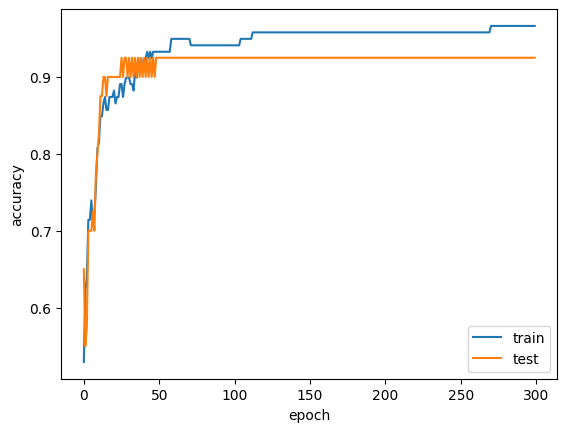

In [109]:
#300번의 에포크 동안 기록한 훈련 세트와 테스트 세트의 점수를 그래프로 그려보자

import matplotlib.pyplot as plt

plt.plot(train_score, label = 'train')
plt.plot(test_score, label = "test")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
# 그래프 결과 100번째 훈련시 가장 적합한 모양을 보인다.

In [ ]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

# tol : 수렴허용오차, 기본값은 1e-3, 모델의 훈련을 조기 종료하는 기준을 설정
# tol=None : 허용 오차 기준을 무시하고 정해진 최대 반복 횟수(max_iter)만큼 반복

0.957983193277311
0.925


In [113]:
# 힌지손실을 이용하여 구하여 보자
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925
